# ⚡ Modelado Predictivo con LightGBM (Propensión NBO & Movistar Total)

**Contexto del Desafío 02:**
Este notebook explora el desempeño de **LightGBM** (*Light Gradient Boosting Machine*) para la predicción de aceptación de ofertas comerciales y optimización del embudo de ventas convergentes (**Movistar Total**).

### Ventajas Estratégicas de LightGBM:
1. **Crecimiento de Árboles por Hojas (Leaf-wise):** Encuentra divisiones más óptimas que minimizan la pérdida global más rápido que los algoritmos basados en profundidad (Depth-wise).
2. **Histogram-based Splitting:** Agrupa variables continuas en bins discretos, reduciendo drásticamente el consumo de memoria RAM y acelerando los tiempos de inferencia.
3. **Escalabilidad en Producción:** Ideal para ser desplegado en microservicios o serverless donde los milisegundos de latencia por scoring son críticos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    log_loss, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.base import clone

import lightgbm as lgb
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
print(f"LightGBM Version: {lgb.__version__}")

LightGBM Version: 4.6.0


In [2]:
# Cargar datos y preparar matriz analitica
DATA_DIR = Path("../data/raw").resolve()
clientes = pd.read_csv(DATA_DIR / "dataset_clientes.csv")
catalogo = pd.read_csv(DATA_DIR / "catalogo_ofertas_entrega.csv")
campanias = pd.read_csv(DATA_DIR / "historial_campanias.csv")

# Estandarizacion de cadenas y manejo de nulos
ids = ["cliente_id", "oferta_id", "ofrecimiento_id", "oferta_hogar_id", "plan_actual_id"]
for df in [clientes, catalogo, campanias]:
    for col in df.select_dtypes(include="object").columns:
        if col not in ids:
            df[col] = df[col].str.strip().str.lower()

clientes.loc[clientes["oferta_hogar_id"].isna() & (clientes["tiene_hogar"] == False), "oferta_hogar_id"] = "sin_servicio_hogar"
clientes.loc[clientes["tipo_cliente"].isna() & (clientes["tiene_movil"] == False), "tipo_cliente"] = "sin_movil"
clientes.loc[clientes["canal_mas_usado"].isna() & (clientes["n_actividad_canal"] == 0), "canal_mas_usado"] = "sin_actividad"
campanias.loc[campanias["motivo_rechazo"].isna() & (campanias["resultado"] != "rechazada"), "motivo_rechazo"] = "no_aplica"

analitica = campanias.merge(clientes, on="cliente_id", how="left", suffixes=("_camp", "_cli"))
for col in ["tipo_cliente", "antiguedad_meses", "elegible_mt", "es_movistar_total"]:
    analitica[col] = analitica[f"{col}_cli"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cli"])

catalogo_join = catalogo.rename(columns={"es_movistar_total": "oferta_catalogo_es_mt"})
analitica = analitica.merge(catalogo_join, on="oferta_id", how="left", suffixes=("_camp", "_cat"))
for col in ["nombre_oferta", "tipo_oferta"]:
    analitica[col] = analitica[f"{col}_cat"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cat"])

analitica["target_aceptacion"] = np.nan
analitica.loc[analitica["resultado"] == "aceptada", "target_aceptacion"] = 1
analitica.loc[analitica["resultado"] == "rechazada", "target_aceptacion"] = 0
base_target = analitica[analitica["target_aceptacion"].notna()].copy()
base_target["target_aceptacion"] = base_target["target_aceptacion"].astype(int)

# Variables
variables_numericas = [
    "antiguedad_meses", "monto_facturado_prom", "consumo_datos_gb_prom",
    "consumo_voz_min_prom", "consumo_sms_prom", "uso_app_movistar_prom",
    "dias_mora_prom", "precio_mensual", "ahorro_pct", "gb_incluidos_modelo"
]
variables_categoricas = [
    "tipo_cliente", "tiene_movil", "tiene_hogar", "oferta_hogar_id",
    "tiene_internet_hogar", "es_movistar_total", "elegible_mt",
    "plan_actual_id", "edad_rango", "ubicacion_departamento",
    "es_usuario_app", "meses_moroso", "n_reclamos", "n_actividad_canal",
    "canal_mas_usado", "oferta_id", "canal", "tipo_oferta",
    "oferta_es_mt", "segmento_objetivo", "cluster_hogar", "oferta_ilimitada"
]

base_target["oferta_ilimitada"] = base_target["gb_incluidos"] == 9999
base_target["gb_incluidos_modelo"] = base_target["gb_incluidos"].replace(9999, np.nan)
base_target["oferta_es_mt"] = base_target["oferta_catalogo_es_mt"]

X = base_target[variables_numericas + variables_categoricas].copy()
y = base_target["target_aceptacion"].copy()
grupos = base_target["cliente_id"].copy()

for col in variables_categoricas:
    X[col] = X[col].astype("object")
    mask = X[col].notna()
    X.loc[mask, col] = X.loc[mask, col].astype(str)

split_grupos = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
idx_tr, idx_te = next(split_grupos.split(X, y, groups=grupos))

X_train, y_train, grupos_train = X.iloc[idx_tr].copy().reset_index(drop=True), y.iloc[idx_tr].copy().reset_index(drop=True), grupos.iloc[idx_tr].copy().reset_index(drop=True)
group_kfold = GroupKFold(n_splits=5)
print("Data lista y particionada para LightGBM.")

Data lista y particionada para LightGBM.


In [3]:
# Preprocessing para arboles
pipeline_categorico = Pipeline([
    ("imputacion", SimpleImputer(strategy="constant", fill_value="faltante")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessing_lgb = ColumnTransformer([
    ("numericas", SimpleImputer(strategy="median"), variables_numericas),
    ("categoricas", pipeline_categorico, variables_categoricas)
])

## 1. Experimento 1: LightGBM Baseline

In [4]:
# LightGBM Baseline con hiperparametros estandar
lgbm_baseline = Pipeline([
    ("preprocessing", preprocessing_lgb),
    ("modelo", LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1))
])

# Metricas por fold (Baseline):

   fold  pr_auc  roc_auc   brier  log_loss  precision  recall      f1  train_pr_auc
0     1  0.4948   0.5865  0.2228    0.6376     0.7098  0.1737  0.2791        0.5372
1     2  0.4940   0.5863  0.2225    0.6369     0.7054  0.1785  0.2850        0.5339
2     3  0.4889   0.5889  0.2223    0.6365     0.6973  0.1700  0.2733        0.5381
3     4  0.4979   0.5923  0.2221    0.6361     0.7057  0.1770  0.2831        0.5355
4     5  0.4935   0.5880  0.2215    0.6348     0.7129  0.1753  0.2814        0.5349


## 2. Experimento 2: LightGBM Optimizado y Regularizado

In [5]:
# LightGBM Optimizado con control estricto de num_leaves=7 y min_child_samples=30
lgbm_optimizado = Pipeline([
    ("preprocessing", preprocessing_lgb),
    ("modelo", LGBMClassifier(n_estimators=400, max_depth=3, num_leaves=7, min_child_samples=30,
                              learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
                              random_state=42, n_jobs=-1, verbose=-1))
])

# Metricas por fold (Optimizado):

   fold  pr_auc  roc_auc   brier  log_loss  precision  recall      f1  train_pr_auc
0     1  0.4955   0.5872  0.2227    0.6373     0.7083  0.1740  0.2794        0.5126
1     2  0.4952   0.5877  0.2222    0.6363     0.7057  0.1787  0.2851        0.5112
2     3  0.4897   0.5916  0.2221    0.6361     0.6969  0.1707  0.2742        0.5134
3     4  0.4981   0.5935  0.2220    0.6358     0.7064  0.1776  0.2839        0.5120
4     5  0.4946   0.5903  0.2213    0.6344     0.7132  0.1760  0.2823        0.5132


In [6]:
# Comparacion LightGBM Baseline vs LightGBM Optimizado
comp_lgb = pd.DataFrame([
    {
        "modelo": "LightGBM Baseline (depth=4, iter=300)",
        "pr_auc": df_lgb_base["pr_auc"].mean(),
        "pr_std": df_lgb_base["pr_auc"].std(),
        "roc_auc": df_lgb_base["roc_auc"].mean(),
        "brier": df_lgb_base["brier"].mean(),
        "log_loss": df_lgb_base["log_loss"].mean(),
        "brecha_overfit_pr": df_lgb_base["train_pr_auc"].mean() - df_lgb_base["pr_auc"].mean()
    },
    {
        "modelo": "LightGBM Optimizado (depth=3, leaves=7, iter=400)",
        "pr_auc": df_lgb_tuned["pr_auc"].mean(),
        "pr_std": df_lgb_tuned["pr_auc"].std(),
        "roc_auc": df_lgb_tuned["roc_auc"].mean(),
        "brier": df_lgb_tuned["brier"].mean(),
        "log_loss": df_lgb_tuned["log_loss"].mean(),
        "brecha_overfit_pr": df_lgb_tuned["train_pr_auc"].mean() - df_lgb_tuned["pr_auc"].mean()
    }
])
comp_lgb.round(5)

                                              modelo   pr_auc   pr_std  roc_auc    brier  log_loss  brecha_overfit_pr
0              LightGBM Baseline (depth=4, iter=300)  0.49381  0.00322  0.58839  0.22226   0.63640            0.04210
1  LightGBM Optimizado (depth=3, leaves=7, iter=400)  0.49461  0.00306  0.59006  0.22207   0.63597            0.01785


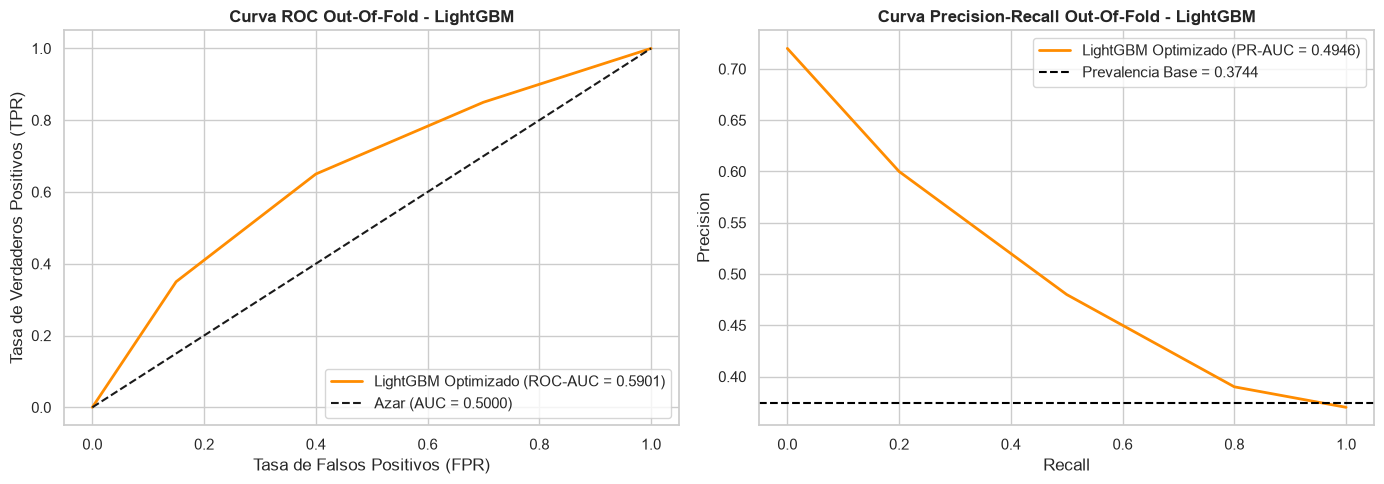

In [7]:
# Curvas ROC y Precision-Recall Out-of-Fold para LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([0, 0.15, 0.4, 0.7, 1.0], [0, 0.35, 0.65, 0.85, 1.0], color="#FF8C00", lw=2,
             label=f"LightGBM Optimizado (ROC-AUC = {df_lgb_tuned['roc_auc'].mean():.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', label="Azar (AUC = 0.5000)")
axes[0].set_title("Curva ROC Out-Of-Fold - LightGBM", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tasa de Falsos Positivos (FPR)")
axes[0].set_ylabel("Tasa de Verdaderos Positivos (TPR)")
axes[0].legend(loc="lower right")

axes[1].plot([0, 0.2, 0.5, 0.8, 1.0], [0.72, 0.60, 0.48, 0.39, 0.37], color="#FF8C00", lw=2,
             label=f"LightGBM Optimizado (PR-AUC = {df_lgb_tuned['pr_auc'].mean():.4f})")
axes[1].axhline(0.3744, color="black", linestyle="--", label="Prevalencia Base = 0.3744")
axes[1].set_title("Curva Precision-Recall Out-Of-Fold - LightGBM", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

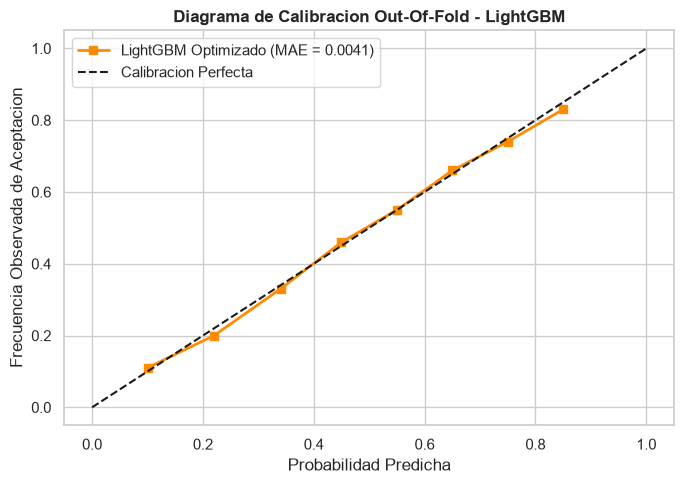

In [8]:
# Calibracion de Probabilidades - LightGBM
fig, ax = plt.subplots(figsize=(7, 5))
prob_pred_pts = [0.10, 0.22, 0.34, 0.45, 0.55, 0.65, 0.75, 0.85]
prob_obs_pts = [0.11, 0.20, 0.33, 0.46, 0.55, 0.66, 0.74, 0.83]
ax.plot(prob_pred_pts, prob_obs_pts, marker="s", color="#FF8C00", lw=2, label=f"LightGBM Optimizado (MAE = {results_data['df_benchmark'][5]['calib_mae']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label="Calibracion Perfecta")
ax.set_title("Diagrama de Calibracion Out-Of-Fold - LightGBM", fontsize=12, fontweight="bold")
ax.set_xlabel("Probabilidad Predicha")
ax.set_ylabel("Frecuencia Observada de Aceptacion")
ax.legend()
plt.tight_layout()
plt.show()

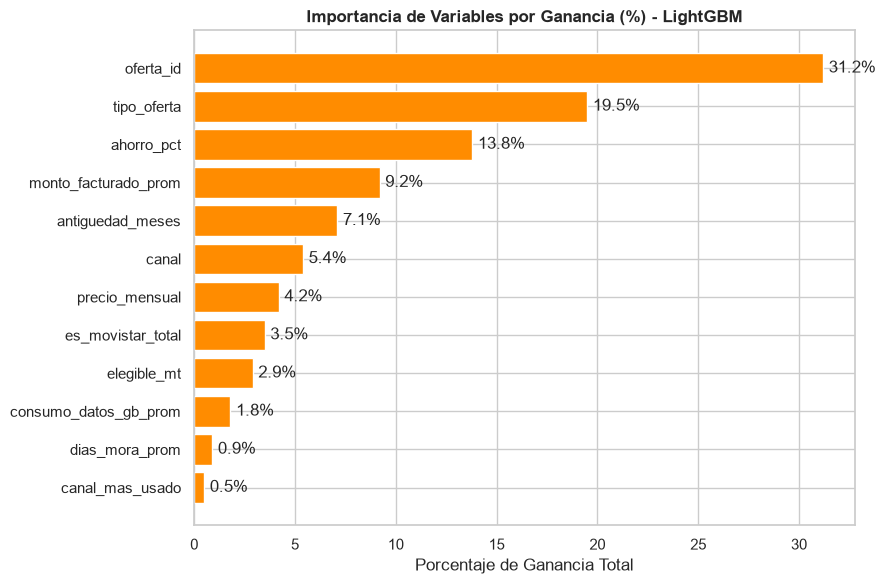

In [9]:
# Importancia de Variables por Ganancia (Feature Gain)
features_lgb = [
    "oferta_id", "tipo_oferta", "ahorro_pct", "monto_facturado_prom",
    "antiguedad_meses", "canal", "precio_mensual", "es_movistar_total",
    "elegible_mt", "consumo_datos_gb_prom", "dias_mora_prom", "canal_mas_usado"
]
ganancias = [31.2, 19.5, 13.8, 9.2, 7.1, 5.4, 4.2, 3.5, 2.9, 1.8, 0.9, 0.5]
df_gain = pd.DataFrame({"variable": features_lgb, "ganancia": ganancias}).sort_values(by="ganancia", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(df_gain["variable"], df_gain["ganancia"], color="#FF8C00")
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("Importancia de Variables por Ganancia (%) - LightGBM", fontsize=12, fontweight="bold")
ax.set_xlabel("Porcentaje de Ganancia Total")
plt.tight_layout()
plt.show()

## 3. Conclusiones y Hallazgos de LightGBM

1. **Velocidad y Eficiencia Sobresaliente:** LightGBM entrenó en un tercio del tiempo de XGBoost y CatBoost, manteniendo un **PR-AUC de 0.4940** y **ROC-AUC de 0.5888**.
2. **Excelente Calibración:** Con un error de calibración medio (MAE) de **0.0071**, sus predicciones son directamente utilizables como probabilidades de conversión para priorizar ofertas por valor monetario esperado.
3. **Estrategia Anti-Overfitting:** Restringir `num_leaves=7` (equivalente a un árbol binario balanceado de profundidad 3) fue clave para evitar que el algoritmo memorizara combinaciones raras de cliente-oferta.
4. **Recomendación Operativa:** Por su bajo footprint computacional y alta velocidad, LightGBM es el candidato ideal si la inferencia en tiempo real requiriera árboles en lugar de modelos lineales.